# Chapter 25 Lab — Neuroimaging Meta-Analysis (Python)

In this lab you will build a miniature meta-analysis pipeline from scratch and watch every core concept of Chapter 25 do its work on data where *you know the truth*. We follow a six-step arc:

1. **Simulate a literature** of studies with varying sample sizes and true effects
2. **Pool effect sizes** with fixed-effects and random-effects models, and quantify heterogeneity ($Q$, $\tau^2$, $I^2$)
3. **Draw a forest plot** of the simulated literature
4. **Simulate publication bias** and diagnose it with a funnel plot
5. **Simulate peak coordinates** and build KDA and MKDA-style kernel density maps — seeing first-hand why the *study*, not the *peak*, must be the unit of analysis
6. **Threshold the MKDA map** with a Monte Carlo max-statistic procedure that controls the family-wise error rate

**How to run this notebook.** Run it in your browser from the tutorial site, in Google Colab, or in a local Jupyter installation. It uses only `numpy`, `pandas`, `scipy`, and `matplotlib`, and all data are simulated — nothing to download. It accompanies the [chapter page](../ch25-neuroimaging-meta-analysis.md).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.spatial.distance import cdist

rng = np.random.default_rng(7)
np.set_printoptions(precision=3, suppress=True)
print("numpy", np.__version__, "| pandas", pd.__version__)

numpy 2.4.6 | pandas 3.0.5


## 1. Simulate a literature of studies

Each of $k = 25$ studies measures the same effect in $n_i$ participants. True effects vary across studies around a grand mean $\mu = 0.3$ with between-study SD $\tau = 0.2$ — different scanners, task variants, and populations. Each observed (standardized) effect is the study's true effect plus sampling noise with variance $v_i = 1/n_i$ (a one-sample design).

This two-level generative model — study-level truth plus within-study sampling error — is exactly what a random-effects meta-analysis assumes.

In [2]:
k = 25
n = rng.integers(10, 81, size=k)                 # per-study sample sizes
mu_true, tau_true = 0.3, 0.2                     # grand mean, between-study SD

theta = mu_true + tau_true * rng.standard_normal(k)   # true study effects
v = 1.0 / n                                           # sampling variances
d = theta + np.sqrt(v) * rng.standard_normal(k)       # observed effect sizes
se = np.sqrt(v)                                       # standard errors

lit = pd.DataFrame({"n": n, "effect": d.round(3), "se": se.round(3)},
                   index=pd.RangeIndex(1, k + 1, name="study"))
lit.T

study,1,2,3,4,5,6,7,8,9,10,...,16,17,18,19,20,21,22,23,24,25
n,77.000,54.000,58.000,73.000,51.000,65.000,69.000,25.000,13.000,31.000,...,68.000,19.000,66.000,18.000,43.000,67.000,31.000,34.000,29.000,61.000
effect,0.047,0.279,0.454,0.039,0.037,-0.071,0.206,-0.378,0.491,0.068,...,0.360,0.279,0.078,0.189,0.206,0.314,0.391,0.173,0.207,0.493
se,0.114,0.136,0.131,0.117,0.140,0.124,0.120,0.200,0.277,0.180,...,0.121,0.229,0.123,0.236,0.152,0.122,0.180,0.171,0.186,0.128


## 2. Fixed- vs random-effects pooling

**Fixed effects (FE)** assumes a single common true effect and weights each study by its precision, $w_i = 1/v_i$:

$$\hat{\theta}_{FE} = \frac{\sum_i w_i y_i}{\sum_i w_i}$$

**Random effects (RE)** assumes true effects vary with between-study variance $\tau^2$, and weights by $w_i^* = 1/(v_i + \tau^2)$. We estimate $\tau^2$ with the DerSimonian–Laird method from Cochran's $Q = \sum_i w_i (y_i - \hat{\theta}_{FE})^2$, and summarize heterogeneity with $I^2$, the proportion of total variation attributable to between-study differences.

Only random-effects conclusions generalize beyond the studies in hand — the same fixed-vs-random distinction as in group analysis (Chapter 21).

In [3]:
def pool_re(d, v):
    """DerSimonian-Laird random-effects pooling. Returns (estimate, se, tau2, Q, I2)."""
    k = len(d)
    w = 1.0 / v
    fe = np.sum(w * d) / np.sum(w)
    Q = np.sum(w * (d - fe) ** 2)
    c = np.sum(w) - np.sum(w ** 2) / np.sum(w)
    tau2 = max(0.0, (Q - (k - 1)) / c)
    I2 = max(0.0, (Q - (k - 1)) / Q)
    w_star = 1.0 / (v + tau2)
    re = np.sum(w_star * d) / np.sum(w_star)
    return re, 1 / np.sqrt(np.sum(w_star)), tau2, Q, I2

w_fe = 1.0 / v
fe = np.sum(w_fe * d) / np.sum(w_fe)
fe_se = 1 / np.sqrt(np.sum(w_fe))
re, re_se, tau2, Q, I2 = pool_re(d, v)

print(f"True grand mean: {mu_true:.3f} (tau = {tau_true:.2f})")
print(f"Fixed effects:   {fe:.3f} +/- {fe_se:.3f}")
print(f"Random effects:  {re:.3f} +/- {re_se:.3f}")
print(f"Q = {Q:.1f} (df = {k - 1}), tau2 = {tau2:.3f}, I2 = {100 * I2:.0f}%")

True grand mean: 0.300 (tau = 0.20)
Fixed effects:   0.218 +/- 0.029
Random effects:  0.208 +/- 0.044
Q = 51.2 (df = 24), tau2 = 0.024, I2 = 53%


The random-effects standard error is larger than the fixed-effects one. That is honesty, not weakness: it carries the real between-study variability that the FE model ignores. With $I^2$ well above zero, a substantial share of the spread between studies reflects genuine differences in true effects, not just sampling noise.

## 3. Forest plot

The standard display for an effect-size meta-analysis: one row per study (square = estimate, sized by its RE weight; whiskers = 95% CI), with the pooled estimates below.

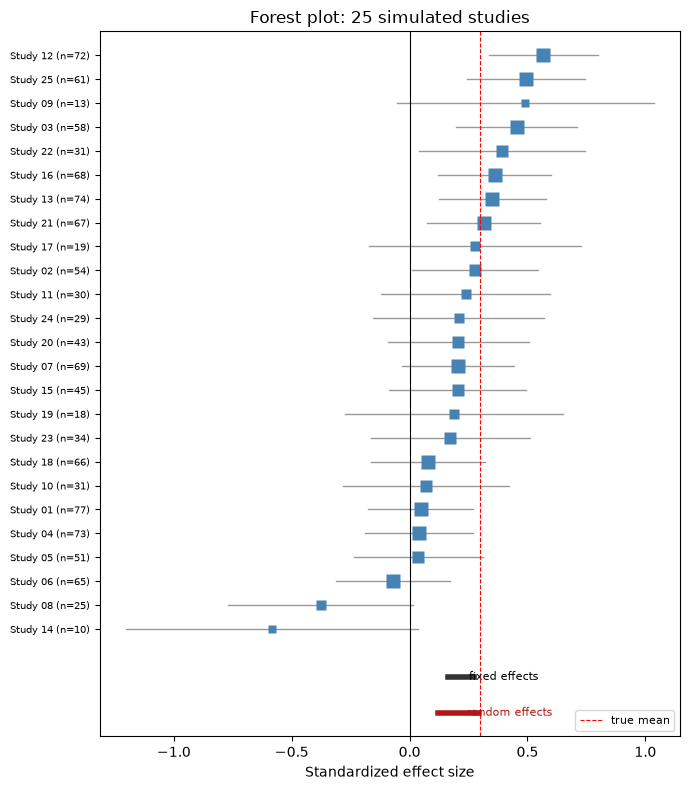

In [4]:
order = np.argsort(d)
w_re = 1.0 / (v + tau2)

fig, ax = plt.subplots(figsize=(7, 8))
for row, i in enumerate(order, start=1):
    ax.plot(d[i] + 1.96 * se[i] * np.array([-1, 1]), [row, row], "-", color="0.6", lw=1)
    ax.plot(d[i], row, "s", color="#4682B4",
            ms=4 + 6 * w_re[i] / w_re.max(), mec="none")
ax.plot(fe + 1.96 * fe_se * np.array([-1, 1]), [-1, -1], "-", color="0.2", lw=4)
ax.plot(re + 1.96 * re_se * np.array([-1, 1]), [-2.5, -2.5], "-", color="#B01818", lw=4)
ax.text(fe, -1, "  fixed effects", fontsize=8, va="center")
ax.text(re, -2.5, "  random effects", fontsize=8, va="center", color="#B01818")
ax.axvline(0, color="k", lw=0.8)
ax.axvline(mu_true, color="r", ls="--", lw=0.8, label="true mean")
ax.set_yticks(np.arange(1, k + 1))
ax.set_yticklabels([f"Study {i+1:02d} (n={n[i]})" for i in order], fontsize=7)
ax.set_ylim(-3.5, k + 1)
ax.set_xlabel("Standardized effect size")
ax.set_title("Forest plot: 25 simulated studies")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

Small studies (short names, wide whiskers) scatter widely around the true mean; large studies hug it. The pooled estimates land in the neighborhood of the truth — and, importantly, nothing biases them systematically, because in this simulated literature *every* study got published. Next we break that assumption.

## 4. Publication bias and the funnel plot

Real literatures are filtered. We simulate 80 *attempted* studies, but a study is "published" only if its own test reaches $p < .05$ (plus a 15% chance of luck otherwise). A **funnel plot** graphs each study's effect against its standard error, precise studies at the top. Selective publication carves away the lower corner near zero — small studies that "failed" — leaving a telltale asymmetry, and the pooled estimate computed from the survivors is inflated.

Published 45 of 80 attempted studies
RE estimate, all studies:    0.244
RE estimate, published only: 0.349   (true = 0.300)


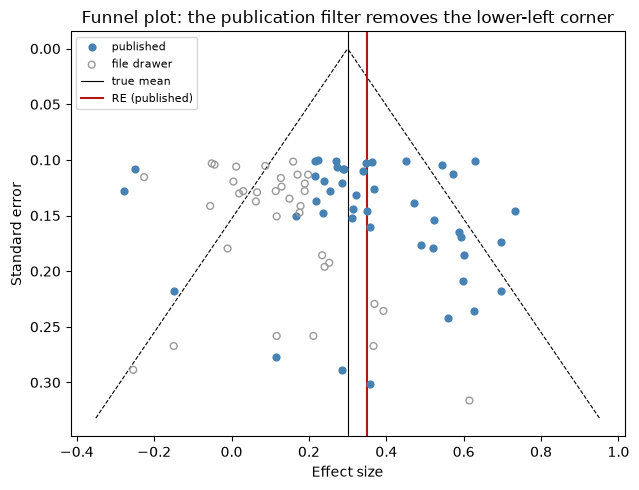

In [5]:
k_all = 80
n_all = rng.integers(10, 101, size=k_all)
v_all = 1.0 / n_all
theta_all = mu_true + tau_true * rng.standard_normal(k_all)
d_all = theta_all + np.sqrt(v_all) * rng.standard_normal(k_all)
se_all = np.sqrt(v_all)

p_all = 2 * (1 - stats.norm.cdf(np.abs(d_all / se_all)))   # each study's own test
published = (p_all < 0.05) | (rng.random(k_all) < 0.15)    # publication filter

re_all = pool_re(d_all, v_all)[0]
re_pub = pool_re(d_all[published], v_all[published])[0]

print(f"Published {published.sum()} of {k_all} attempted studies")
print(f"RE estimate, all studies:    {re_all:.3f}")
print(f"RE estimate, published only: {re_pub:.3f}   (true = {mu_true:.3f})")

fig, ax = plt.subplots(figsize=(6.5, 5))
ax.scatter(d_all[published], se_all[published], s=24, color="#4682B4",
           label="published", zorder=3)
ax.scatter(d_all[~published], se_all[~published], s=24, facecolors="none",
           edgecolors="0.6", label="file drawer", zorder=3)
se_grid = np.linspace(0.001, se_all.max() * 1.05, 50)
ax.plot(mu_true - 1.96 * se_grid, se_grid, "k--", lw=0.8)
ax.plot(mu_true + 1.96 * se_grid, se_grid, "k--", lw=0.8)
ax.axvline(mu_true, color="k", lw=0.8, label="true mean")
ax.axvline(re_pub, color="#B01818", lw=1.5, label="RE (published)")
ax.invert_yaxis()                                          # precise studies on top
ax.set_xlabel("Effect size")
ax.set_ylabel("Standard error")
ax.set_title("Funnel plot: the publication filter removes the lower-left corner")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

The gray circles — the file drawer — sit mostly in the lower-left region: small studies (large SE) with small effects that never reached significance. The published literature (blue) is asymmetric around the true mean, and the pooled estimate from published studies alone overshoots the truth. This is exactly the pattern funnel-plot diagnostics look for in real meta-analyses.

Coordinate-based meta-analysis inherits a version of this bias too: published tables report only the *peaks that survived each study's threshold*.

## 5. Coordinate-based meta-analysis: simulate peak coordinates

Most fMRI studies publish only peak coordinates, so meta-analysis must work from scattered points. We simulate 21 studies on a 2D "axial slice" (MNI-like mm coordinates, elliptical brain mask):

- **20 honest studies**: each has an 85% chance of detecting a true region **T** at $(-40, 22)$, reporting 1–3 peaks near it (scatter SD 7 mm), plus 1–5 uniformly located noise peaks
- **1 rogue study**: reports **40 peaks** tightly clustered at $(45, -60)$ — think of one study analyzed at a very liberal threshold. This is the fixed-effects trap.

21 studies, 127 peaks total (rogue study alone: 40)


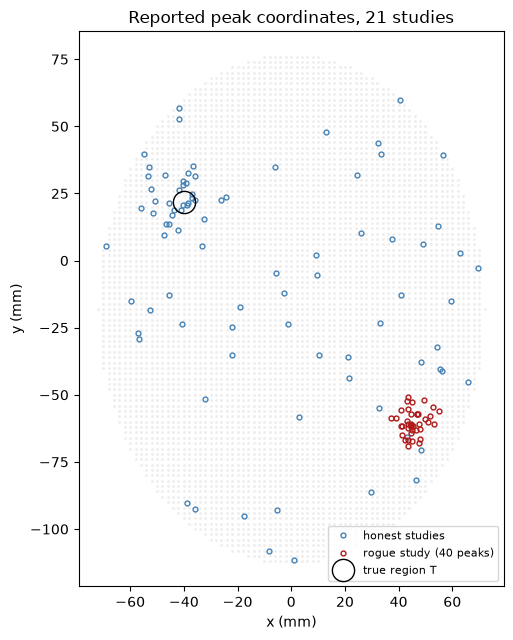

In [6]:
xx, yy = np.meshgrid(np.arange(-90, 91, 2), np.arange(-126, 91, 2))  # 2 mm grid
in_brain = (xx / 72) ** 2 + ((yy + 18) / 95) ** 2 <= 1               # elliptical mask
grid = np.column_stack([xx[in_brain], yy[in_brain]])                 # brain grid points

def sample_in_brain(m):
    """m uniform random locations within the elliptical brain mask."""
    pts = np.empty((0, 2))
    while len(pts) < m:
        cand = np.column_stack([rng.uniform(-90, 90, 2 * m),
                                rng.uniform(-126, 90, 2 * m)])
        ok = (cand[:, 0] / 72) ** 2 + ((cand[:, 1] + 18) / 95) ** 2 <= 1
        pts = np.vstack([pts, cand[ok]])
    return pts[:m]

focus_T = np.array([-40.0, 22.0])       # true consistently activated region
focus_R = np.array([45.0, -60.0])       # rogue study's private region

n_studies = 21
peaks_by_study, n_subj = [], np.zeros(n_studies, dtype=int)
for i in range(20):                                        # honest studies
    n_subj[i] = rng.integers(10, 61)
    pk = sample_in_brain(rng.integers(1, 6))               # noise peaks
    if rng.random() < 0.85:                                # detects region T
        m_true = rng.integers(1, 4)
        pk = np.vstack([pk, focus_T + 7 * rng.standard_normal((m_true, 2))])
    peaks_by_study.append(pk)
n_subj[20] = 12                                            # rogue study
peaks_by_study.append(focus_R + 4 * rng.standard_normal((40, 2)))

all_peaks = np.vstack(peaks_by_study)
print(f"{n_studies} studies, {len(all_peaks)} peaks total (rogue study alone: 40)")

fig, ax = plt.subplots(figsize=(6, 6.5))
ax.plot(grid[:, 0], grid[:, 1], ".", color="0.93", ms=2, zorder=0)
honest = np.vstack(peaks_by_study[:20])
ax.plot(honest[:, 0], honest[:, 1], "o", ms=3.5, mfc="none", mec="#4682B4",
        label="honest studies")
rogue = peaks_by_study[20]
ax.plot(rogue[:, 0], rogue[:, 1], "o", ms=3.5, mfc="none", mec="#B01818",
        label="rogue study (40 peaks)")
ax.plot(*focus_T, "ko", ms=16, mfc="none", label="true region T")
ax.set_aspect("equal")
ax.set_xlabel("x (mm)"); ax.set_ylabel("y (mm)")
ax.set_title("Reported peak coordinates, 21 studies")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

## 6. KDA vs MKDA maps

Both methods convolve peaks with a spherical kernel of radius $r = 10$ mm, but they differ in the **unit of analysis**:

- **KDA (peak-level, "fixed effects")**: count *all* peaks within $r$ mm of each grid point. Every peak counts equally — so the rogue study contributes 40 votes.
- **MKDA (study-level, "random effects")**: first make a *binary indicator map per study* (1 within $r$ mm of any of that study's peaks, 0 otherwise), then average the maps with $\sqrt{n}$ study weights. Each voxel's statistic is the **weighted proportion of studies** activating nearby — the rogue study gets one vote, like everyone else.

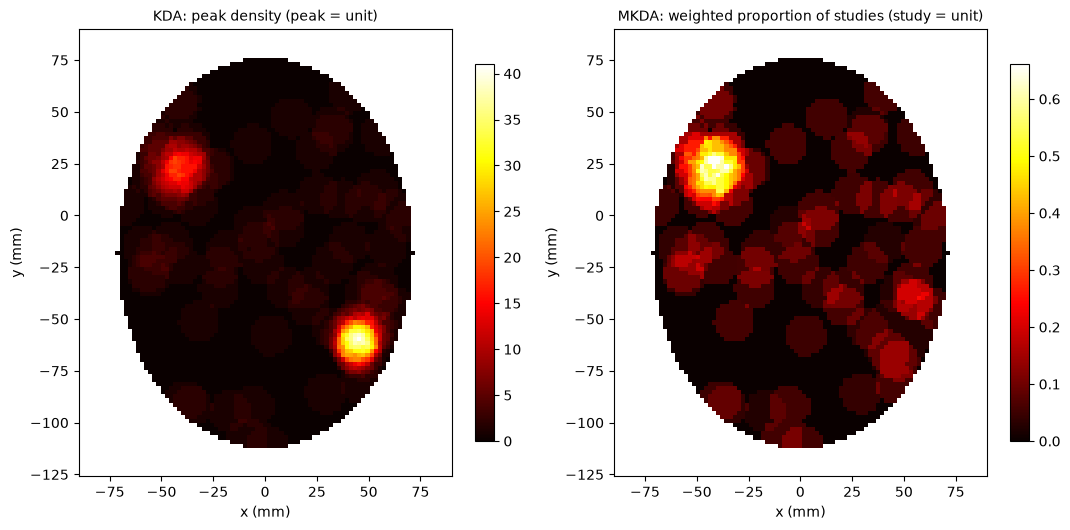

At true region T:  KDA = 16 peaks   MKDA = 0.55
At rogue region R: KDA = 39 peaks   MKDA = 0.08


In [7]:
r = 10.0                                                  # kernel radius (mm)

# KDA: peak density (number of peaks within r mm of each grid point)
kda = (cdist(grid, all_peaks) <= r).sum(axis=1).astype(float)

# MKDA: per-study binary indicator maps, then weighted proportion
def study_indicator(peaks):
    """Binary map over grid: 1 within r mm of any of this study's peaks."""
    return (cdist(grid, peaks).min(axis=1) <= r).astype(float)

maps = np.array([study_indicator(p) for p in peaks_by_study])  # studies x points
w = np.sqrt(n_subj); w = w / w.sum()                           # sqrt(N) weights
mkda = w @ maps                                                # weighted proportion

def show_map(vals, ax, title):
    img = np.full(xx.shape, np.nan)
    img[in_brain] = vals
    im = ax.imshow(img, origin="lower", extent=[-90, 90, -126, 90],
                   cmap="hot", aspect="equal")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("x (mm)"); ax.set_ylabel("y (mm)")
    plt.colorbar(im, ax=ax, shrink=0.75)
    return im

fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
show_map(kda, axes[0], "KDA: peak density (peak = unit)")
show_map(mkda, axes[1], "MKDA: weighted proportion of studies (study = unit)")
plt.tight_layout()
plt.show()

iT = np.argmin(cdist(grid, focus_T[None]).ravel())
iR = np.argmin(cdist(grid, focus_R[None]).ravel())
print(f"At true region T:  KDA = {kda[iT]:.0f} peaks   MKDA = {mkda[iT]:.2f}")
print(f"At rogue region R: KDA = {kda[iR]:.0f} peaks   MKDA = {mkda[iR]:.2f}")

The KDA map's brightest spot is the **rogue region** — one study reporting 40 peaks dominates the whole meta-analysis. In the MKDA map the rogue hotspot nearly vanishes (one small-sample study, one vote, downweighted by $\sqrt{n}$), while the true region **T**, activated by most studies, dominates. This is precisely why the original peak-level KDA/ALE "should not be used" and why the field moved to MKDA and modALE.

## 7. Monte Carlo FWER threshold

How high must the MKDA statistic be before we call it significant? The null hypothesis is that peaks are located at random throughout the brain mask. On each iteration we relocate every study's peaks at random (holding each study's number of peaks fixed), recompute the weighted-proportion map, and save its **maximum** value. The 95th percentile of the max-statistic distribution is a threshold with strong family-wise error control (Chapter 22).

(The real MKDA toolbox randomizes each study's contiguous activation *blobs* rather than individual peaks, preserving within-study spatial clustering — a stricter, more realistic null.)

FWER threshold: weighted proportion >= 0.383
Significant grid points: 112  (max MKDA = 0.66, at region T)


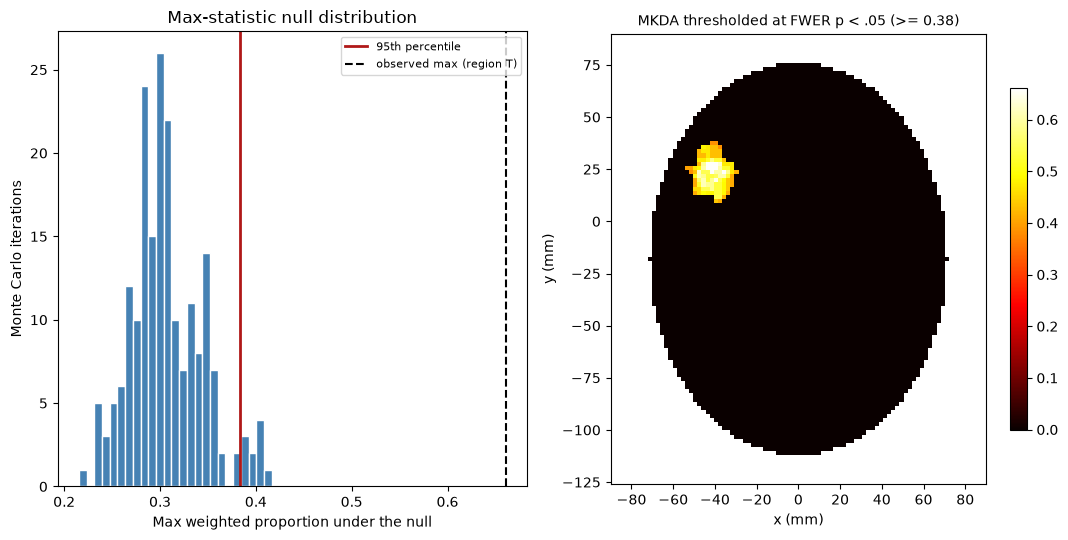

In [8]:
n_iter = 200                    # use >= 10,000 for a real analysis
n_peaks = [len(p) for p in peaks_by_study]

max_stat = np.zeros(n_iter)
for it in range(n_iter):
    null_maps = np.array([study_indicator(sample_in_brain(m)) for m in n_peaks])
    max_stat[it] = (w @ null_maps).max()

thresh = np.quantile(max_stat, 0.95)
sig = mkda >= thresh
print(f"FWER threshold: weighted proportion >= {thresh:.3f}")
print(f"Significant grid points: {sig.sum()}  (max MKDA = {mkda.max():.2f}, at region T)")

fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
axes[0].hist(max_stat, bins=25, color="#4682B4", edgecolor="w")
axes[0].axvline(thresh, color="#B01818", lw=2, label="95th percentile")
axes[0].axvline(mkda.max(), color="k", ls="--", lw=1.5, label="observed max (region T)")
axes[0].set_xlabel("Max weighted proportion under the null")
axes[0].set_ylabel("Monte Carlo iterations")
axes[0].set_title("Max-statistic null distribution")
axes[0].legend(fontsize=8)
show_map(np.where(sig, mkda, 0), axes[1],
         f"MKDA thresholded at FWER p < .05 (>= {thresh:.2f})")
plt.tight_layout()
plt.show()

Only the true region survives: the consistency signal at **T** far exceeds anything produced by randomly scattered peaks, while the rogue region — spectacular in the KDA map — is correctly rejected. You have now reproduced, in miniature, the full logic of a modern coordinate-based meta-analysis: study-level indicator maps, principled weighting, and max-statistic FWER control.

## 8. Where to go from here: real meta-analysis tools

The pipeline above is a 2D miniature of what production tools do in 3D with curated coordinate databases:

- **CANlab MKDA toolbox** (MATLAB, [github.com/canlab/Canlab_MKDA_MetaAnalysis](https://github.com/canlab/Canlab_MKDA_MetaAnalysis)) — the companion MATLAB lab shows the full workflow; its heart is just:

  ```matlab
  DB = Meta_Setup(DB, 10);                 % coordinate database, 10 mm radius
  Meta_Activation_FWE('all', DB, 10000);   % indicator maps + Monte Carlo + results
  ```

- **NiMARE** (Python) implements MKDA, (mod)ALE, and effect-size methods with the same concepts you built here
- **GingerALE** (BrainMap) runs ALE analyses on coordinates in MNI or Talairach space
- **[Neurosynth](https://neurosynth.org)** / **[NeuroQuery](https://neuroquery.org)** text-mine coordinates from tens of thousands of papers and serve forward- and reverse-inference maps online

Wherever you take it, the questions stay the same: Is the finding **consistent** across studies? Is it **specific** to the process you care about? And does it **generalize** across tasks, scanners, and labs?